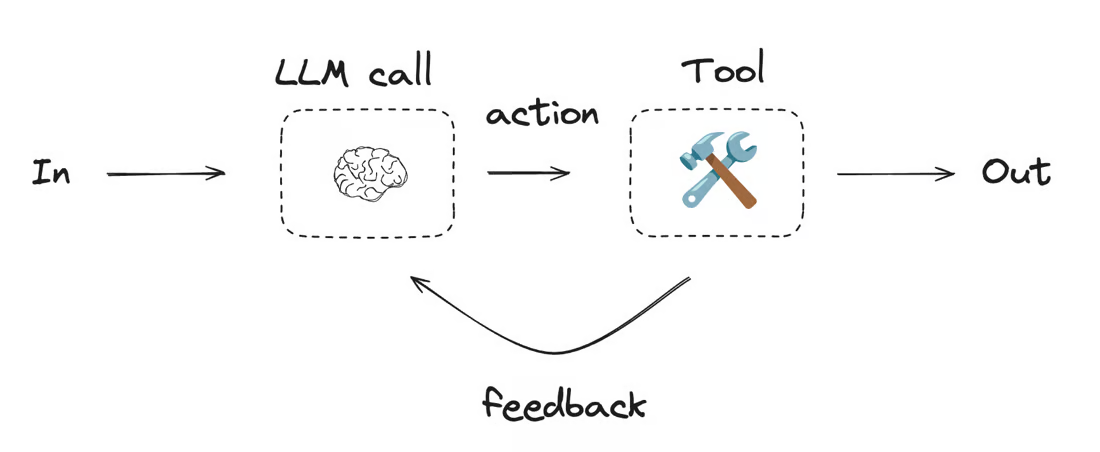

In [ ]:
import os
from pathlib import Path

from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name != "agent-arch":
    raise RuntimeError("Start Jupyter from the agent-arch folder.")

env_file = PROJECT_ROOT / ".env"
load_dotenv(env_file)
if not os.getenv("OPENAI_API_KEY"):
    raise RuntimeError(f"Add OPENAI_API_KEY to {env_file}")

llm = ChatOpenAI(
    model="gpt-5.6-terra",
    reasoning_effort="none",
    request_timeout=30,
    max_retries=1,
)

In [ ]:
from langchain.tools import tool


# Define tools
@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b


# Augment the LLM with tools
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)

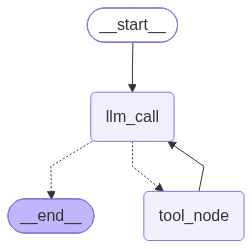

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (call_SnCmxBT6e1MCcPUxm6uS34mV)
 Call ID: call_SnCmxBT6e1MCcPUxm6uS34mV
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================

7


In [ ]:
from typing import Literal

from IPython.display import Image, display
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langgraph.graph import END, START, MessagesState, StateGraph


# Nodes
def llm_call(state: MessagesState):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            llm_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ]
    }


def tool_node(state: MessagesState):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}


# Conditional edge function to route to the tool node or end based upon whether the LLM made a tool call
def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return END


# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END],
)
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# Invoke
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

## Evaluator - Optimizer for jokes sample  

In [ ]:
from pydantic import BaseModel, Field


class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="Decide if joke is funny or not"
    )
    feedback: str = Field(
        description="If the joke is not funny, provide feedback on how to improve it"
    )


evaluator = llm.with_structured_output(Feedback)

In [ ]:
from typing_extensions import TypedDict


class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str
    attempts: int


def llm_call_generator(state: State):
    if state.get("feedback"):
        msg = llm.invoke(
            f"Write a joke about {state['topic']} but take into account of the feedback: {state['feedback']}"
        )
    else:
        msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content, "attempts": state.get("attempts", 0) + 1}


def llm_call_eval(state: State):
    grade = evaluator.invoke(f"Grade the joke {state['joke']}")
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}


def route_joke(state: State) -> Literal["llm_call_generator", END]:
    if state["funny_or_not"] == "funny" or state["attempts"] >= 3:
        return END  # ponytail: cap paid retries; raise only if quality warrants it.
    return "llm_call_generator"

In [ ]:
## build graph

optimizer_builder = StateGraph(State)

optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_call_eval", llm_call_eval)
optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_eval")
optimizer_builder.add_conditional_edges(
    "llm_call_eval",
    route_joke,
    ["llm_call_generator", END],
)

optimizer_workflow = optimizer_builder.compile()

display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

for step in optimizer_workflow.stream({"topic": "Cats"}, stream_mode="updates"):
    print(step)